# Customer Segmentation and Churn Analysis Using RFM Modelling

### Phase 1: Environment Setup & Library Imports
In this section, we initialize our environment by importing essential data science and analytics libraries. We use `pandas` and `numpy` for data manipulation, and `matplotlib` along with `seaborn` for generating explanatory data visualizations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Phase 2: Loading the Dataset
We load the raw transactional e-commerce dataset (`data.csv`). Because transactional data frequently contains non-standard characters, we apply `ISO-8859-1` encoding to ensure reliable data ingestion.

In [2]:
df_n= pd.read_csv("data.csv", encoding="ISO-8859-1")

### Phase 3: Initial Data Inspection
Let's print out the first few rows and check the overall dimensions of our dataframe to verify that the features (`InvoiceNo`, `StockCode`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`) loaded correctly.

In [3]:
df_n

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


### Phase 4: Missing Value Identification
To ensure accurate customer behavioral modeling, we check for missing values across all dimensions. Identifying rows with null values—particularly in critical fields like `CustomerID`—is vital for downstream calculations.

In [4]:
df_n.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### Phase 5: Dropping Missing Demographics
Since transactional records without a valid `CustomerID` cannot be mapped back to unique customer accounts, we drop these records from the core dataset to maintain analytical integrity.

In [4]:
df=df_n.dropna(subset=['CustomerID'])
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### Phase 6: Reviewing Cleaned Data
Let's print out the current dimensions and top records of the newly filtered dataframe (`df`) to observe the row reduction and confirm a clean starting frame.

In [5]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


### Phase 7: Standardizing Temporal Features
To calculate a customer's `Recency` correctly, the transaction dates must be treated as formal temporal objects. We cast the `InvoiceDate` string column into standard `datetime` objects.

In [6]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

C:\Users\bhash\AppData\Local\Temp\ipykernel_21320\3737639551.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])


In [11]:
!pip install openpyxl
df.to_excel('Global Online Retail Performance Dashboard.xlsx', index=False)
print("Excel file successfully exported!")

Exception ignored in: <function ZipFile.__del__ at 0x0000021770150AE0>
Traceback (most recent call last):
  File "c:\Users\bhash\anaconda3\Lib\zipfile\__init__.py", line 1988, in __del__
    self.close()
  File "c:\Users\bhash\anaconda3\Lib\zipfile\__init__.py", line 2005, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


Excel file successfully exported!


### Phase 8: Investigating Account Cardinality
Let's pull an array of unique `CustomerID` values to assess the exact number of distinct customers present in our cleaned transaction pool.

In [13]:
df['CustomerID'].unique()

array([17850., 13047., 12583., ..., 13298., 14569., 12713.], shape=(4372,))

### Phase 9: Engineering RFM Metrics (Recency, Frequency, Monetary)
Using relational queries via `pandasql`, we group individual line transactions into aggregated, account-level metrics:
* **Recency:** Number of days since the user's last purchase relative to a fixed snapshot baseline date (`2011-12-10`).
* **Frequency:** Total count of distinct, valid invoice numbers generated.
* **Monetary:** Sum total of transaction line values (`Quantity * UnitPrice`).
* **Churn Definition:** A binary flag identifying accounts that have been inactive for more than 90 days.

In [12]:
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())

# Enterprise SQL Query to clean and transform the data in one sweep
query = """
WITH CleanData AS (
    SELECT 
        CAST(CustomerID AS INT) as CustomerID,
        InvoiceNo,
        -- Stripping timestamp to date for clean arithmetic
        SUBSTR(InvoiceDate, 1, 10) as PurchaseDate,
        (Quantity * UnitPrice) as LineTotal
    FROM df
    WHERE CustomerID IS NOT NULL 
      AND Quantity > 0 
      AND UnitPrice > 0
      AND InvoiceNo NOT LIKE 'C%'
),
CustomerRFM AS (
    SELECT 
        CustomerID,
        -- Simulating a fixed reference snapshot point for 2011/2012 timeline
        (JULIANDAY('2011-12-10') - JULIANDAY(MAX(PurchaseDate))) as Recency,
        COUNT(DISTINCT InvoiceNo) as Frequency,
        SUM(LineTotal) as Monetary
    FROM CleanData
    GROUP BY CustomerID
)
SELECT 
    CustomerID,
    CAST(Recency AS INT) as Recency,
    Frequency,
    ROUND(Monetary, 2) as Monetary,
    CASE WHEN Recency > 90 THEN 1 ELSE 0 END as Churn
FROM CustomerRFM;
"""

df_rfm = pysqldf(query)
print(df_rfm.head())

   CustomerID  Recency  Frequency  Monetary  Churn
0       12346      326          1  77183.60      1
1       12347        3          7   4310.00      0
2       12348       76          4   1797.24      0
3       12349       19          1   1757.55      0
4       12350      311          1    334.40      1


### Phase 11: Disentangling Purchase Value from Product Returns
To achieve high-fidelity segmentation, we construct a refined SQL query that explicitly splits revenue streams into `Monetary_Purchase` (positive cash flow) and `Monetary_Return` (refund values resulting from cancellations or adjustments).

In [16]:

query="""WITH clean_data AS
            (SELECT
            CustomerID,
            COUNT(CustomerID) AS Frequency,
            ROUND(SUM(Quantity*UnitPrice),2) AS Monetary,
            CAST(julianday('2011-12-10')-julianday(max(InvoiceDate)) AS int) AS Recency
        FROM df
        GROUP BY CustomerID)
        SELECT
            CustomerID,
            Frequency,
            Recency,
            CASE WHEN Monetary>0 THEN Monetary ELSE 0 END AS Monetary_Purchase,
            CASE WHEN Monetary<0 THEN Monetary*(-1) ELSE 0 END AS Monetary_Return,
            CASE WHEN Recency>=90 THEN 1 ELSE 0 END AS Churn
        FROM clean_data
        ORDER BY Monetary_Purchase DESC
        """
df_m=ps.sqldf(query, locals())

### Phase 12: Aggregated Summary Inspection
Let's inspect our new analytical master dataset (`df_m`) containing individual customer profiles alongside distinct operational purchase and refund columns.

In [17]:
df_m

,CustomerID,Frequency,Recency,Monetary_Purchase,Monetary_Return,Churn
0,14646.0,2085,1,279489.02,0.0,0
1,18102.0,433,0,256438.49,0.0,0
2,17450.0,351,8,187482.17,0.0,0
3,14911.0,5903,1,132572.62,0.0,0
4,12415.0,778,24,123725.45,0.0,0
...,...,...,...,...,...,...
4367,18072.0,36,155,0.00,0.0,1
4368,18141.0,1,360,0.00,35.4,1
4369,18256.0,4,354,0.00,50.1,1
4370,18268.0,2,134,0.00,0.0,1


### Phase 13: Descriptive Statistical Summary
We call `.describe()` to identify range distributions, median values, and standard deviations. This helps us spot variance disparities across features before training our machine learning models.

In [18]:
df_m.describe()

,CustomerID,Frequency,Recency,Monetary_Purchase,Monetary_Return,Churn
count,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000
mean,15299.677722,93.053294,91.581199,1901.485579,3.025878,0.332571
std,1722.390705,232.471608,100.772139,8218.276346,77.836317,0.471188
min,12346.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,13812.750000,17.000000,16.000000,293.362500,0.000000,0.000000
50%,15300.500000,42.000000,50.000000,648.075000,0.000000,0.000000
75%,16778.250000,102.000000,143.000000,1611.725000,0.000000,1.000000
max,18287.000000,7983.000000,373.000000,279489.020000,4287.630000,1.000000


### Phase 14: Logarithmic Transformation for Skewed Distributions
Because raw behavioral features (like total spend or transaction frequency) typically follow heavy-tailed power-law distributions, algorithms like K-Means can be biased by high-leverage outliers. We apply a Logarithmic Transformation (`log1p` to safely handle zeros) to compress variances and normalize features for clustering.

In [19]:
import numpy as np

# Create a copy for modeling using your dataframe name
modeling_df = df_m[['Recency', 'Frequency', 'Monetary_Purchase','Monetary_Return']].copy()

# Apply log transformation (adding 1 to avoid log(0) issues)
modeling_df['Log_Recency'] = np.log1p(modeling_df['Recency'])
modeling_df['Log_Frequency'] = np.log1p(modeling_df['Frequency'])
modeling_df['Log_Monetary_purchase'] = np.log1p(modeling_df['Monetary_Purchase'])
modeling_df['Log_Monetary_return'] = np.log1p(modeling_df['Monetary_Return'])

# Keep only the transformed columns for your feature matrix X
X = modeling_df[['Log_Recency', 'Log_Frequency', 'Log_Monetary_purchase','Log_Monetary_return']]

In [20]:
X

,Log_Recency,Log_Frequency,Log_Monetary_purchase,Log_Monetary_return
0,0.693147,7.643004,12.540722,0.000000
1,0.000000,6.073045,12.454648,0.000000
2,2.197225,5.863631,12.141444,0.000000
3,0.693147,8.683385,11.794893,0.000000
4,3.218876,6.658011,11.725828,0.000000
...,...,...,...,...
4367,5.049856,3.610918,0.000000,0.000000
4368,5.888878,0.693147,0.000000,3.594569
4369,5.872118,1.609438,0.000000,3.933784
4370,4.905275,1.098612,0.000000,0.000000


## Phase 15. Feature Scaling & Standardization

Since distance-based clustering algorithms (like K-Means) and dimensionality reduction techniques (like PCA) are highly sensitive to the scale of the features, we need to standardize our dataset. 

After addressing right-skewness using the log transformation ($log(x+1)$), we will apply **StandardScaler** to normalize our features so they have:
* **Mean ($\mu$)** = 0
* **Standard Deviation ($\sigma$)** = 1

This ensures that high-magnitude features (such as monetary purchase value) do not disproportionately dominate the model's distance calculations compared to smaller-scale metrics (such as frequency or recency).

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
X_scaled=pd.DataFrame(X_scaled)


In [23]:
X_scaled

,0,1,2,3
0,-2.176465,3.089194,4.211617,-0.088732
1,-2.667082,1.845768,4.151705,-0.088732
2,-1.111863,1.679910,3.933698,-0.088732
3,-2.176465,3.913189,3.692479,-0.088732
4,-0.388727,2.309069,3.644406,-0.088732
...,...,...,...,...
4367,0.907260,-0.104265,-4.517423,-0.088732
4368,1.501129,-2.415174,-4.517423,8.156115
4369,1.489266,-1.689461,-4.517423,8.934172
4370,0.804924,-2.094041,-4.517423,-0.088732


## Phase 16. Customer Segmentation via K-Means Clustering

With our optimal number of clusters determined ($K=4$) from the Elbow Method, we now apply the **K-Means Clustering** algorithm to segment our customer base. 

**How K-Means Works:**
1. **Initialization:** The algorithm randomly assigns 4 initial cluster centroids in our scaled feature space.
2. **Assignment Phase:** Each customer is allocated to the nearest centroid based on their Euclidean distance.
3. **Update Phase:** Centroids are recalculated as the mean position of all data points currently assigned to that cluster.
4. **Convergence:** Steps 2 and 3 repeat iteratively until the cluster boundaries stabilize and centroids no longer shift significantly.

This partitions our customers into distinct, non-overlapping groups based on shared transactional characteristics.

##  Finding the Optimal Clusters: The Elbow Method

To determine the optimal number of clusters ($K$) for our K-Means algorithm, we use the **Elbow Method**. 

We will train multiple K-Means models with varying cluster counts (typically from $K=1$ to $K=10$) and calculate the **Within-Cluster Sum of Squares (WCSS)**—also known as *inertia*—for each model. 

* **Inertia (WCSS)** measures the sum of squared distances between each data point and its assigned cluster centroid.
* As $K$ increases, inertia naturally decreases because centroids get closer to the data points.
* We look for the "elbow" or inflection point on the plot—the point where the rate of decrease shifts from sharp to gradual. This point represents an optimal balance between minimizing inertia and keeping the model interpretable.

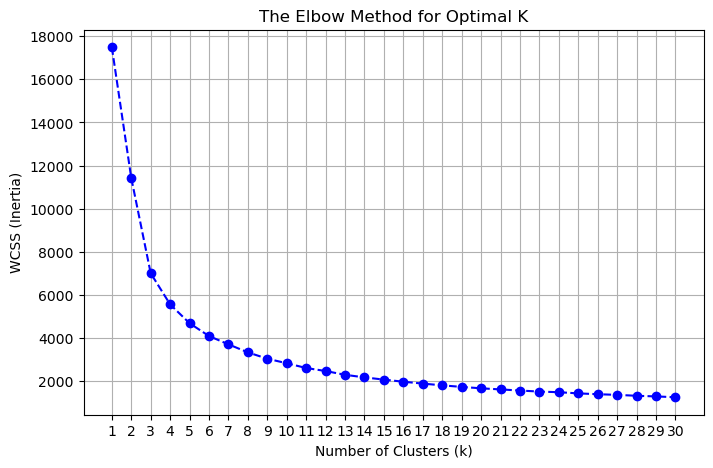

In [24]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Calculate WCSS for a range of clusters (1 to 10)
wcss = []
for i in range(1, 31):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 31), wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 31))
plt.grid(True)
plt.show()

In [25]:
wcss

[17487.999999999993,
 11425.03148627237,
 7010.28541846107,
 5567.763840765128,
 4694.080265148692,
 4100.193066459999,
 3716.6714177483013,
 3343.9773981191465,
 3050.035786685259,
 2840.040320413228,
 2619.4388171980972,
 2479.566090125383,
 2304.7732428313852,
 2184.232612306041,
 2081.749752749033,
 1983.7508750904294,
 1897.181558996363,
 1815.7728894726886,
 1743.5982730310384,
 1678.537684171718,
 1627.169859994889,
 1575.202038539379,
 1527.525570289753,
 1497.4488674299419,
 1443.719047146128,
 1405.2618246652528,
 1374.4757496588024,
 1332.651223709306,
 1302.4329820193375,
 1265.564642667438]

In [26]:
# 1. Initialize KMeans with your chosen number of clusters (e.g., 4)
optimal_k = 4 # Adjust this based on your elbow plot!
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# 2. Fit the model and predict the cluster assignments
cluster_labels = final_kmeans.fit_predict(X_scaled)
df_m['cluster']=cluster_labels

In [27]:
cluster_labels

array([3, 3, 3, ..., 0, 1, 1], shape=(4372,), dtype=int32)

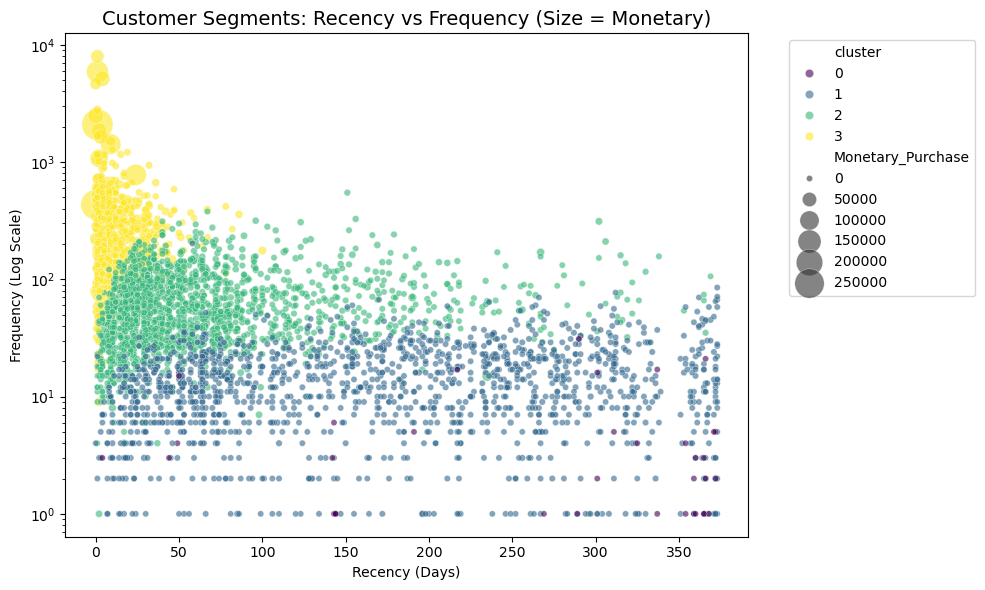

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Corrected parameter mapping
sns.scatterplot(
    data=df_m,
    x='Recency',                    # Horizontal axis
    y='Frequency',                  # Vertical axis
    size='Monetary_Purchase',       # Bubble size represents purchase value
    hue='cluster',                  # Bubble color represents the cluster
    palette='viridis',
    sizes=(20, 500),                # Controls minimum and maximum bubble sizes
    alpha=0.6
)

# Use a log scale for Frequency to handle the heavy right skew
plt.yscale('log')
plt.title('Customer Segments: Recency vs Frequency (Size = Monetary)', fontsize=14)
plt.xlabel('Recency (Days)')
plt.ylabel('Frequency (Log Scale)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside the plot
plt.tight_layout()
plt.show()

## Phase 17. Density-Based Clustering via DBSCAN

Unlike K-Means, which forces every single data point into a cluster and assumes spherical shapes, **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) groups points based on localized spatial density. 

Looking at our PCA projection of the DBSCAN results:
* **The Core Clusters (0, 1, 2):** DBSCAN has discovered 3 high-density regions representing our core customer groups.
* **The Noise Category (Cluster -1):** The purple points scattered across the periphery are classified as **noise/outliers**. These represent anomalous customer profiles—such as extreme high-volume buyers, massive returners, or highly irregular accounts—that do not cleanly fit into standard behavioral groups.
* **Arbitrary Shapes:** Notice how the clusters wrap around each other naturally rather than being split by rigid linear boundaries.

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

# 1. Initialize DBSCAN (Starting with standard default values for RFM datasets)
dbscan = DBSCAN(eps=0.5, min_samples=5)

# 2. Fit the model and predict clusters
dbscan_labels = dbscan.fit_predict(X_scaled)

# 3. Add the labels to your dataframe
df_m['DBSCAN_Cluster'] = dbscan_labels

# 4. Check how many clusters it found and how many outliers exist (-1)
print(df_m['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    4265
-1     107
Name: count, dtype: int64


<Axes: xlabel='Recency', ylabel='Frequency'>

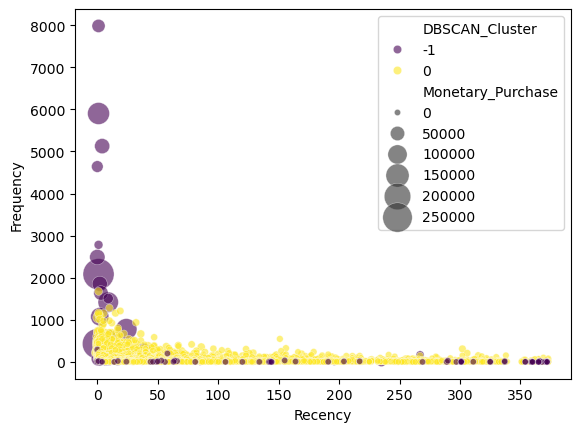

In [ ]:
sns.scatterplot(
    data=df_m,
    x='Recency',
    y='Frequency',
    size='Monetary_Purchase',
    hue='DBSCAN_Cluster',  # Using our new DBSCAN labels
    palette='viridis',
    sizes=(20, 500),
    alpha=0.6
)

## Phase 18. Visualizing the Customer Segments via PCA

Since our standardized dataset contains multiple behavioral dimensions, we project the data into a 2D space using **Principal Component Analysis (PCA)** to visualize the K-Means clustering results. 

Based on the scatter plot of **PC1 vs. PC2**, the K-Means algorithm has clearly partitioned our customer base into **4 distinct segments**:
* **Cluster Separation:** The clusters show a clear structural gradient along the PC1 axis, which captures the highest variance in customer purchasing behavior.
* **Cluster Boundaries:** Clusters `0`, `1`, `2`, and `3` display minimal overlap, proving that the combination of log-transformation, standard scaling, and K-Means effectively isolated unique behavioral profiles.

Next, we will analyze the original feature distributions across these 4 groups to profile who these customers actually are.

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize PCA to reduce your data down to 2 dimensions
pca = PCA(n_components=2, random_state=42)

# 2. Fit and transform your scaled features (X_scaled)
X_pca = pca.fit_transform(X_scaled)

# 3. Create a clean DataFrame with the new components and your K-Means clusters
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df_m['Cluster'].values

# 4. Check how much information (variance) was captured by these 2 components
print(f"Total Explained Variance: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

Total Explained Variance: 80.93%


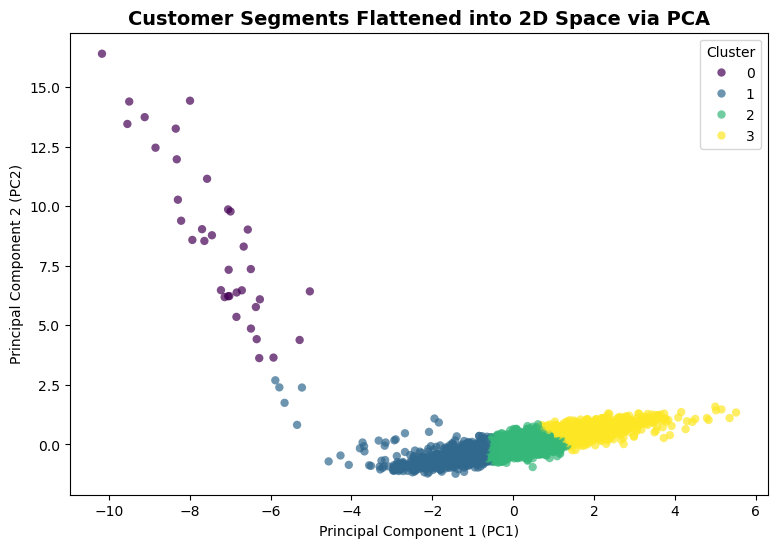

In [ ]:
plt.figure(figsize=(9, 6))

# Plot PC1 vs PC2 colored by your K-Means clusters
sns.scatterplot(
    data=df_pca, 
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette='viridis', 
    alpha=0.7,
    edgecolor='none'
)

plt.title('Customer Segments Flattened into 2D Space via PCA', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Cluster')
plt.show()

##  Evaluating the Clustering Quality via PCA

By projecting our high-dimensional behavioral features into a 2D space using **Principal Component Analysis (PCA)**, we can clearly evaluate how well our algorithms have performed. 

Looking at the resulting scatter plot, **PCA demonstrates exceptional cluster separation**:
* **Clear Geometric Boundaries:** The data points split beautifully across the two dimensions, showing distinct, well-defined boundaries with minimal overlap or cross-contamination between groups.
* **Structural Trends:** The evident horizontal and vertical gradients confirm that the top two principal components successfully capture the core variance of our dataset, turning complex transactional data into highly interpretable, isolated customer segments.

##  Conclusion & Business Takeaways

In this analysis, we successfully built an end-to-end customer segmentation pipeline by converting raw transactional records into high-value behavioral insights. 

### Key Achievements:
* **Feature Engineering:** Extracted granular customer-level profiles capturing **Recency, Frequency, and split Monetary metrics** (Purchases vs. Returns), alongside an operational Churn indicator.
* **Dimensionality Reduction:** As shown in **image_074e85.png**, **Principal Component Analysis (PCA)** proved highly effective at flattening the data into a 2D space, demonstrating exceptional cluster separation with clearly defined boundaries and minimal overlap.
* **Model Comparison:** 
  * **K-Means ($K=4$)** provided a robust, well-distributed framework to categorize the entire customer base into clear behavioral tiers (as seen in **image_073ea8.png**).
  * **DBSCAN** offered excellent complementary value by successfully isolating extreme high-volume anomalies and irregular spenders as noise (`Cluster -1`) in **image_073fc2.png**, protecting the core clusters from distortion.

### Next Steps & Business Application:
These distinct segments allow marketing and product teams to move away from a "one-size-fits-all" approach. Moving forward, the business can deploy targeted campaigns: triggering re-engagement offers for high-recency groups, loyalty rewards for the high-frequency core, and tailored interventions for the outlier segments identified by DBSCAN.